In [1]:
import yaml
import joblib
import re
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from typing import TypedDict, Annotated
from functools import partial
from PIL import Image
from io import BytesIO
from IPython.display import Markdown

from agent_procs import llm_detect_intents, llm_revenue_agent, llm_expenditure_agent, llm_answer_writer

with open('secret.key') as key_file:
    api_key = key_file.readline().strip('\n').strip()

In [2]:
with open('config.yaml', 'rb') as yaml_file:
    config=yaml.safe_load(yaml_file)

In [3]:
embeddings = HuggingFaceEmbeddings(model_name='google/embeddinggemma-300m')

In [4]:
try:
    chroma_vectorstore = Chroma(
        collection_name=config['collection_name'],
        persist_directory=config['chroma_dir'],
        embedding_function=embeddings,
        create_collection_if_not_exists=False
    )
    dense_retriever = chroma_vectorstore.as_retriever(
        search_type='similarity',
        search_kwargs={'k': config['retrieval_k']},
    )
    with open(config['bm25_index_path'], 'rb') as bm25_file:
        sparse_retriever = joblib.load(bm25_file)

    hybrid_retriever = EnsembleRetriever(
        retrievers=[dense_retriever, sparse_retriever],
        weights=[config['vector_search_weightage'], (1-config['vector_search_weightage'])],
    )
except:
    print('[Error] Vector database or bm25 index missing, please run part1_1 script first')

In [5]:
class State(TypedDict):
    history: Annotated[list[BaseMessage], add_messages]
    user_query: str
    detected_intents: str
    supervisor_routing: list[str]

    revenue_agent_answer: str
    expenditure_agent_answer: str

    issue_log: list[str]
    final_answer: str

In [6]:
def node_supervisor(state:State, llm)->dict:
    print('[node_supervisor]')
    user_query = state['user_query']
    issue_log = []

    detected_intents = llm_detect_intents(llm, user_query)
    routing = []
    if detected_intents.requires_revenue_agent:
        routing.append('revenue_agent')
    if detected_intents.requires_expenditure_agent:
        routing.append('expenditure_agent')
        
    if not routing:
        issue_log.append('[node_supervisor] No clear revenue or expenditure intent detected')
    
    return {
        'user_query': user_query,
        'detected_intents' : detected_intents.intent_summary,
        'supervisor_routing': routing,
        'issue_log': issue_log
    }

def route_to_agents(state:State) -> list[str]:
    return state['supervisor_routing']

def node_revenue_agent(state:State, llm, rag_retriever)->dict:
    print('[node_revenue_agent]')
    user_query = state['user_query']

    agent_response = llm_revenue_agent(llm, user_query, rag_retriever)
    return {
        'revenue_agent_answer': agent_response.content
    }

def node_expenditure_agent(state:State, llm, rag_retriever)->dict:
    print('[node_expenditure_agent]')
    user_query = state['user_query']

    agent_response = llm_expenditure_agent(llm, user_query, rag_retriever)
    return {
        'expenditure_agent_answer': agent_response.content
    }

def node_answer_writer(state:State, llm)->dict:
    print('[node_answer_writer]')
    user_query = state['user_query']
    revenue_agent_answer = state.get('revenue_agent_answer', '[No findings given]')
    expenditure_agent_answer = state.get('expenditure_agent_answer', '[No findings given]')

    final_answer = llm_answer_writer(llm, user_query, revenue_agent_answer, expenditure_agent_answer)
    return {
        'final_answer': final_answer.content
    }

In [7]:
def build_graph(llm):
    g = StateGraph(State)

    g.add_node('supervisor', partial(node_supervisor, llm=llm))
    g.add_node('revenue_agent', partial(node_revenue_agent, llm=llm, rag_retriever=hybrid_retriever))
    g.add_node('expenditure_agent', partial(node_expenditure_agent, llm=llm, rag_retriever=hybrid_retriever))
    g.add_node('final_answer_writer', partial(node_answer_writer, llm=llm))

    g.add_edge(START, 'supervisor')
    g.add_conditional_edges('supervisor', route_to_agents, ['revenue_agent', 'expenditure_agent'])
    g.add_edge('revenue_agent', 'final_answer_writer')
    g.add_edge('expenditure_agent', 'final_answer_writer')
    g.add_edge('final_answer_writer', END)

    return g.compile()

In [8]:
def extract_final_answer(llm_text):
    final_answer = ''
    answer_text = re.search(r"<answer>(.*?)</answer>", llm_text, re.DOTALL)
    if not answer_text:
        final_answer += '[Error] LLM did not return in <answer> tags as prompted\n'
        final_answer += llm_text
    else:
        final_answer = answer_text.group(1).strip()
    return final_answer

In [9]:
llm = ChatAnthropic(
    model_name='claude-sonnet-5',
    max_tokens=4096,
    timeout=30,
    max_retries=2,
    anthropic_api_key=api_key
)

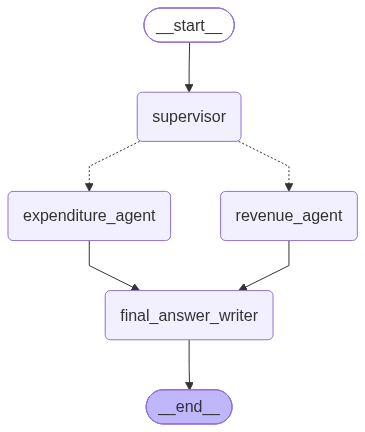

In [10]:
app = build_graph(llm)
image = Image.open(BytesIO(app.get_graph(xray=True).draw_mermaid_png()))
display(image)


In [11]:
query = 'What are the key government revenue streams, and how will the Budget for the Future Energy Fund be supported?'

final_state = app.invoke({
    'user_query': query,
    'history': [HumanMessage(content=query)]
})

display(Markdown(extract_final_answer(final_state['final_answer'][1]['text'])))

[node_supervisor]
[node_expenditure_agent]
[node_revenue_agent]
[node_answer_writer]


**Note on data limitations:** Both agents found that the available source material (fy2024_analysis_of_revenue_and_expenditure.pdf) does not contain a comprehensive breakdown of Singapore's major revenue streams (e.g., GST, corporate income tax, personal income tax, vehicle quota premiums). Only a few specific revenue-related line items appear in the excerpts reviewed. This answer is limited to what was found.

**1. Government Revenue Streams (as found in context, FY2024):**

- **Statutory Boards' Contributions**: Estimated to **decrease by $0.4 billion (58.8%) to $0.3 billion**, mainly due to expected lower contributions from the Monetary Authority of Singapore (Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13). Historical data is referenced as being in "Tables 3.2a and 3.2b in the Statistical Annex," which was not included in the reviewed excerpts.

- **Capitalisation of Nationally Significant Infrastructure**: Projected at **$4.1 billion** for FY2024, up $0.6 billion (17.1%) from the Revised FY2023 figure of $3.5 billion, covering capitalised expenditure on projects such as the North South Corridor, Deep Tunnel Sewerage System, Cross Island Line, and Jurong Region Line (Source: Page 15; Revised FY2023 figure, Page 7).

- **SINGA Interest Costs and Loan Expenses**: Projected at **$0.4 billion** for FY2024 (up from $0.2 billion Revised FY2023 — a 78.6% increase). Note: this is a borrowing-related cost item, not strictly a revenue stream (Source: Page 15, Page 7).

- **Net Investment Returns Contribution**: This appears only as a section heading (Section 2.4, Page 15) in the table of contents; no specific figures were available in the reviewed context.

No further detail on core tax revenues or fees/charges was available from either agent.

**2. Future Energy Fund — Budget Support (FY2024):**

Both the Revenue and Expenditure Agents independently confirmed the same details:

- The Government will establish the **Future Energy Fund** with an **initial injection of $5.0 billion** "to invest in critical infrastructure for the energy transition" (Source: Page 18).
- This is reflected in two budget tables:
  - **Table 2.1 (Budget for FY2024)**, row 30: Future Energy Fund — Estimated FY2024 = **$5.00 billion** (Page 16)
  - **Table 2.4 (Top-ups to Endowment and Trust Funds in FY2024)**, row 1: Future Energy Fund — Estimated FY2024 = **$5,000 million** (Page 20)
- This $5.0 billion injection forms part of the broader **$20.4 billion in total Fund top-ups** committed under Budget 2024, alongside:
  - GST Voucher Fund: $6.0 billion
  - Edusave Endowment Fund: $2.0 billion
  - National Research Fund: $1.8 billion
  - National Productivity Fund: $2.0 billion
  - Financial Sector Development Fund: $2.0 billion
  - Progressive Wage Credit Scheme (PWCS) Fund: $1.0 billion
  - Skills Development Fund: $500 million
  - Public Transport Fund: $50 million
  - Legal Aid Fund: $2 million
  (Source: Page 18)

**Important caveat:** Neither agent found a specific dedicated revenue source, tax, or levy earmarked to fund the Future Energy Fund. Rather, it is financed as a **Special Transfer / Fund top-up** out of the Government's overall Budget 2024 fiscal resources, alongside the other endowment and trust fund top-ups listed above — not tied to any particular revenue stream in the available excerpts.

In [12]:
query = 'Where does money come from for the government in 2024'

final_state = app.invoke({
    'user_query': query,
    'history': [HumanMessage(content=query)]
})

display(Markdown(extract_final_answer(final_state['final_answer'][1]['text'])))

[node_supervisor]
[node_revenue_agent]
[node_answer_writer]


Based on the Revenue Agent's findings (Expenditure Agent findings were not provided, so this answer covers revenue sources only), here is where the Singapore government's money came from in FY2024 (1 April 2024 – 31 March 2025):

**Total Operating Revenue**
- Estimated at **$108.6 billion** (15.1% of GDP), an increase of **$4.3 billion (4.2%)** over the Revised FY2023 Operating Revenue.
 *(Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13)*

**Key components of this revenue:**

- **Personal Income Tax**: **$18.1 billion**, up $0.5 billion (3.1%), driven by nominal wage growth in 2023 and the increase in the top marginal tax rate effective from Year of Assessment 2024.
 *(Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13)*

- **Assets Taxes** (Property Tax and Estate Duty): **$6.7 billion**, up $0.8 billion (12.8%), due to increased Property Tax rates (effective 1 January 2024) and higher property Annual Values.
 *(Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13)*

- **Motor Vehicle Tax**: **$2.8 billion**, up $0.2 billion (9.3%), reflecting an expected recovery in COE quota supply.
 *(Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13)*

- **Statutory Boards' Contributions**: **$0.3 billion**, down $0.4 billion (58.8%), largely due to expected lower contributions from the Monetary Authority of Singapore.
 *(Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13)*

**Additional inflow supporting the Budget (non-Operating Revenue item):**
- **Net Investment Returns Contribution (NIRC)**: **$23.5 billion**, factored into the Overall Fiscal Position. This is offset in part by Top-ups to Endowment/Trust Funds ($20.4 billion) and Capitalisation of Nationally Significant Infrastructure ($4.1 billion).
 *(Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13)*

**Data Gaps:**
The provided findings do not include FY2024 dollar figures for other major revenue lines such as Corporate Income Tax, GST, Customs and Excise Duties, or Vehicle Quota Premiums. The source document notes that more detailed historical revenue data is available in "Tables 3.2a and 3.2b in the Statistical Annex" (Page 13), which was not included in the supplied context.

**Note:** No Expenditure Agent findings were available, so this answer addresses only the revenue side (where money comes from) and not how it is spent.

In [13]:
query = 'Where are the largest cost savings possible in 2023'

final_state = app.invoke({
    'user_query': query,
    'history': [HumanMessage(content=query)]
})

display(Markdown(extract_final_answer(final_state['final_answer'][1]['text'])))

[node_supervisor]
[node_expenditure_agent]
[node_answer_writer]


No revenue-related findings were available for this query, so the answer below is based solely on the Expenditure Agent's analysis.

**Areas identified with lower-than-estimated expenditure (cost savings) in FY2023 (Revised):**

According to the *fy2024_analysis_of_revenue_and_expenditure.pdf* (Page 6), overall expenditure increases in FY2023 were "partly offset by lower expenditure" in three agencies:

1. **Ministry of Manpower (MOM)** — savings due to lower utilisation for the Jobs Growth Incentive.
2. **Ministry of Education (MOE)** — savings due to lower expenditure on manpower.
3. **Ministry of Home Affairs (MHA)** — savings due to lower manpower costs, expected delays in IT projects, and savings in systems maintenance.

(Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 6)

**Important limitation:** The source document only describes these savings qualitatively — it does **not** provide specific dollar or percentage figures for MOM, MOE, or MHA individually. As a result, it is not possible to determine precisely which of these three areas represents the "largest" saving in FY2023, only that these are the three areas explicitly identified as having lower expenditure than estimated.

For additional context (though not a saving): **Development Expenditure** was revised **upward** to $21.5 billion, an increase of $1.0 billion (4.9%) versus the Estimated FY2023 figure (Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 6). This is a cost increase, not a savings area, and is unrelated to the query.

No other explicit statements about FY2023 expenditure savings (in dollar terms) were found in the available context. If you need the exact dollar magnitude of the MOM, MOE, or MHA savings, additional source data beyond what was provided would be required.

In [14]:
query = 'What is the most important policy in 2024'

final_state = app.invoke({
    'user_query': query,
    'history': [HumanMessage(content=query)]
})

display(Markdown(extract_final_answer(final_state['final_answer'][1]['text'])))

[node_supervisor]
[node_expenditure_agent]
[node_revenue_agent]
[node_answer_writer]


**Important caveat:** Neither the Revenue Agent's nor the Expenditure Agent's source material — Singapore's *FY2024 Analysis of Revenue and Expenditure*, presented to Parliament on 2024-02-16 — explicitly identifies or ranks a single "most important policy" for 2024. Both agents independently confirmed this. What follows is a synthesis of the largest and most prominent fiscal figures in that document, which can be used as a proxy for policy priority based on magnitude of allocation, not an explicit editorial ranking from the source.

**Key FY2024 fiscal highlights (fy2024_analysis_of_revenue_and_expenditure.pdf):**

1. **Top-ups to Endowment and Trust Funds — $20.4 billion total** (Page 13). This is the largest discretionary spending commitment reported, broken down as (Table 2.4, Page 20; also Table 2.1, Page 16):
   - **Future Energy Fund: $5,000 million ($5.00 billion)** — the single largest individual fund top-up, suggesting a strong policy emphasis on energy transition/security.
   - National Productivity Fund: $2,000 million
   - Progressive Wage Credit Scheme Fund: $1,000 million
   - Skills Development Fund: $500 million

2. **Operating Revenue**: Estimated FY2024 Operating Revenue is **$108.6 billion (15.1% of GDP)**, up $4.3 billion (4.2%) over the Revised FY2023 figure (Page 13).

3. **Net Investment Returns Contribution (NIRC)**: Estimated at **$23.5 billion**, up $0.6 billion (2.6%) from Revised FY2023 — the largest single fiscal inflow supporting the budget (Page 15).

4. **Capitalisation of Nationally Significant Infrastructure**: Projected at **$4.1 billion**, up $0.6 billion (17.1%) from Revised FY2023, covering the North South Corridor, Deep Tunnel Sewerage System, Cross Island Line, and Jurong Region Line (Page 15) — indicating continued infrastructure development priority.

5. **SINGA Interest Costs and Loan Expenses**: Projected at **$0.4 billion**, up $0.2 billion (78.6%) from Revised FY2023 "due to additional interest costs from additional SGS (Infrastructure) that will be raised in FY2024" (Page 15).

6. **Overall Fiscal Position**: A basic deficit of $6.1 billion (0.8% of GDP) was targeted, but after top-ups and other adjustments, the Overall Fiscal Position is an estimated **surplus of $0.78 billion** (Table 2.1, Page 16), also described as "$0.8 billion (0.1% of GDP)" (Page 13) — a swing from the Revised FY2023 deficit of $(3.57) billion.

**Conclusion:** If "most important policy" is inferred purely from the size of new spending commitments, the **Future Energy Fund top-up of $5.00 billion** stands out as the single largest specific allocation in the FY2024 Budget, pointing to energy-related initiatives as a major policy focus. However, both agents caution that this is an inference based on magnitude of figures reported in the source, not an explicit ranking or statement of importance made in the document itself.

In [15]:
query = 'If inflation surges much higher than expected, how can the government offset that'

final_state = app.invoke({
    'user_query': query,
    'history': [HumanMessage(content=query)]
})

display(Markdown(extract_final_answer(final_state['final_answer'][1]['text'])))

[node_supervisor]
[node_expenditure_agent]
[node_revenue_agent]
[node_answer_writer]


**Short answer: The source material provided does not contain an explicit policy statement on how the government would offset a larger-than-expected inflation surge.** Both the revenue and expenditure findings only reference inflation as either a revenue-correlated variable or a cost driver — not as a scenario with a defined fiscal "offset" mechanism (e.g., a specific contingency reserve, subsidy formula, or drawdown rule).

**What the documents do show (fy2024_analysis_of_revenue_and_expenditure.pdf):**

*On the revenue side (automatic stabilizer-like effects):*
- Corporate Income Tax was "revised to $28.4 billion, which is $4.1 billion (17.0%) higher than the Estimated FY2023 figure due to stronger-than-expected economic growth in 2022" (Page 5).
- Personal Income Tax was "revised to $17.5 billion, which is $0.7 billion (4.1%) higher... due to stronger-than-expected nominal wage growth in 2022" (Page 6) — nominal wage growth often tracks inflation.
- Assets Taxes were "revised to $5.9 billion... due to upward adjustments to Annual Values for residential properties" (Page 6), reflecting how property-based tax revenue can rise with price levels.
- Other Taxes (Foreign Worker Levy, Water Conservation Tax, Land Betterment Charge, Annual Tonnage Tax) were "revised to $8.8 billion, which is $2.1 billion (32.3%) higher... mainly due to higher Land Betterment Charge collections" (Page 5).
- Net Investment Returns Contribution (NIRC), a relatively stable revenue stream, was "Estimated FY2024 NIRC is $23.5 billion, which is $0.6 billion (2.6%) higher than the Revised FY2023 NIRC" (Page 15).

These figures suggest that several tax revenues (Corporate Income Tax, Personal Income Tax, Assets Taxes) tend to rise alongside economic growth and price levels, which could passively help government revenue keep pace with inflation — though this is not described in the source as a deliberate inflation-offset strategy.

*On the expenditure side (inflation as cost driver, plus one relief measure):*
- Inflationary pressure is explicitly cited as a **cost driver**, not something offset: "The higher expenditure is mainly driven by (i) MINDEF due to catching up of projects deferred or disrupted due to COVID-19, acceleration of the SAF's digitalisation and build-up of non-kinetic capabilities, as well as heightened inflationary pressures" (Page 6).
- The closest measure resembling a targeted inflation-relief response is the **Cost-of-Living (COL) Support Package**, bundled into Special Transfers, which were "revised to $27.2 billion, $7.6 billion (38.7%) higher than Estimated FY2023" (Page 7, Table 1.2). However, the source does not explicitly frame this package as a formal "offset mechanism" for inflation surges — it is only described as an additional fiscal requirement announced in September 2023.
- Revised FY2023 Operating Revenue reached "$104.3 billion, $7.6 billion (7.9%) higher than Estimated FY2023, driven by higher tax collections" (Page 5), showing that revenue growth in that year outpaced some of the added expenditure pressures, though again this is not framed as a deliberate offset strategy.

**Conclusion:** Neither the Revenue Agent nor the Expenditure Agent found any explicit fiscal framework, contingency reserve, or policy tool in the source documents specifically designed to counteract an inflation surge beyond expectations (such as automatic subsidy adjustments, reserve drawdowns, or price controls). The only concrete, inflation-adjacent measures identified are (1) tax revenues that naturally scale with economic growth/price levels, and (2) the Cost-of-Living Support Package under Special Transfers. For a definitive answer on inflation-offsetting fiscal policy, you would need to consult additional Ministry of Finance budget policy statements not included in this context.

In [16]:
query = 'What to get for dinner'

final_state = app.invoke({
    'user_query': query,
    'history': [HumanMessage(content=query)]
})

display(Markdown(extract_final_answer(final_state['final_answer'][1]['text'])))

[node_supervisor]


KeyError: 'final_answer'

In [ ]:
# print(f'[supervisor_routing] {final_state['supervisor_routing']}')
# print(f'[detected_intents] {final_state['detected_intents']}')
# print(f'[revenue_agent_answer] {final_state['revenue_agent_answer']}')
# print(f'[expenditure_agent_answer] {final_state['expenditure_agent_answer']}')
# print(f'[final_answer] {final_state['final_answer']}')
# print(f'[issue_log] {final_state['issue_log']}')

dict_keys(['history', 'user_query', 'detected_intents', 'supervisor_routing', 'issue_log'])